# 手寫阿拉伯數字辨識 完整版


## 載入套件


In [1]:
import os
import re
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import skimage
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import MNIST, FashionMNIST
from torchvision.io import read_image

## 檢查GPU


In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入 MNIST 手寫阿拉伯數字資料


In [3]:
# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST("data", train=True, download=True, transform=transforms.ToTensor())

# 下載測試資料
test_ds = MNIST("data", train=False, download=True, transform=transforms.ToTensor())

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


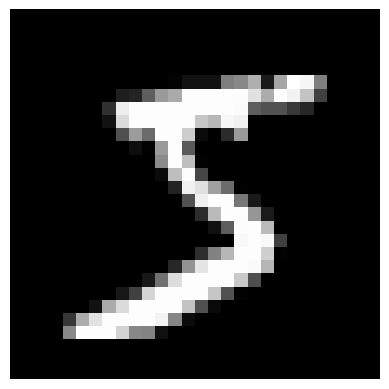

In [4]:
# 顯示第1張圖片圖像
# 第一筆資料
X = train_ds.data[0]

# 繪製點陣圖，cmap='gray':灰階
plt.imshow(X.reshape(28, 28), cmap='gray')

# 隱藏刻度
plt.axis('off')

# 顯示圖形
plt.show()

## FashionMNIST


In [5]:
training_data = FashionMNIST(root="data", train=True, download=True, transform=transforms.ToTensor())

test_data = FashionMNIST(root="data", train=False, download=True, transform=transforms.ToTensor())

## 任意抽樣9筆資料顯示


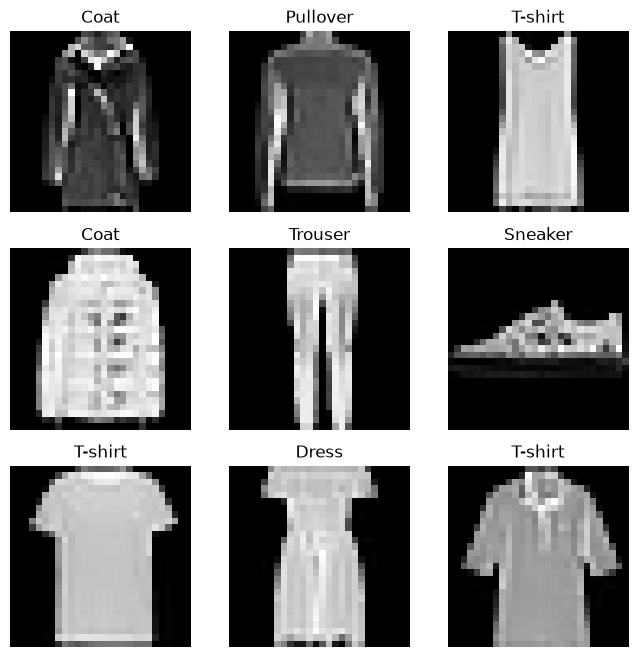

In [6]:
labels_map = {
    0: "T-shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
img: torch.Tensor
for i in range(1, cols * rows + 1):
    sample_idx = int(torch.randint(len(training_data), size=(1,)).item())
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

## Transforms


In [7]:
def plot(imgs: list[Any], with_orig: bool = True, row_title: list[str] | None = None, **imshow_kwargs: Any) -> None:
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0]) + with_orig
    fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        row = [orig_img] + row if with_orig else row
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    if with_orig:
        axs[0, 0].set(title='Original image')
        axs[0, 0].title.set_size(8)
    if row_title is not None:
        for row_idx in range(num_rows):
            axs[row_idx, 0].set(ylabel=row_title[row_idx])

    plt.tight_layout()

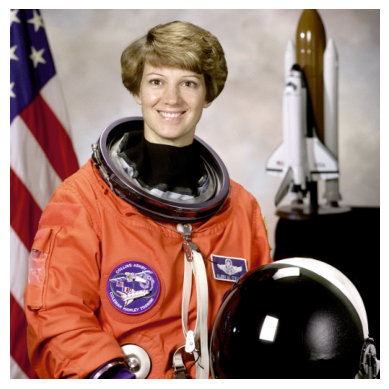

In [8]:
orig_img = skimage.data.astronaut()
skimage.io.imsave('images_test/astronaut.jpg', orig_img)
plt.axis('off')
plt.imshow(orig_img)

In [9]:
# 轉換輸入須為 Pillow 格式
orig_img = Image.open('images_test/astronaut.jpg')

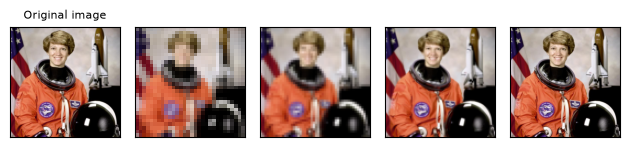

In [10]:
# resize
resized_imgs = [transforms.Resize(size=size)(orig_img) for size in (30, 50, 100, orig_img.size)]
plot(resized_imgs)

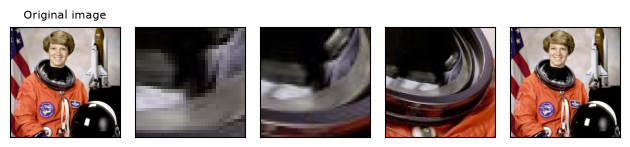

In [11]:
center_crops = [transforms.CenterCrop(size=size)(orig_img) for size in (30, 50, 100, orig_img.size)]
plot(center_crops)

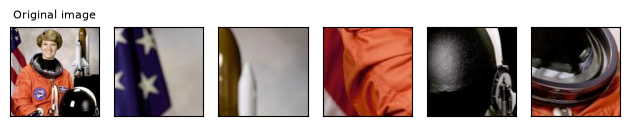

In [12]:
top_left, top_right, bottom_left, bottom_right, center = transforms.FiveCrop(size=(100, 100))(orig_img)
plot([top_left, top_right, bottom_left, bottom_right, center])

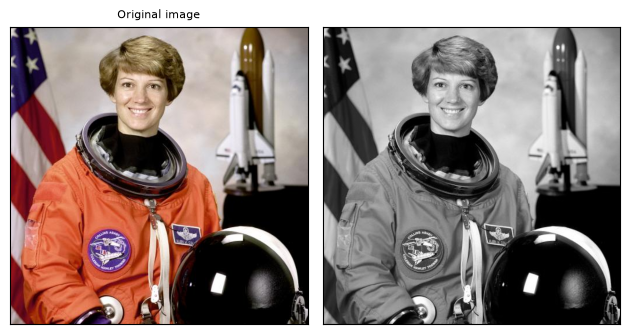

In [13]:
gray_img = transforms.Grayscale()(orig_img)
plot([gray_img], cmap='gray')

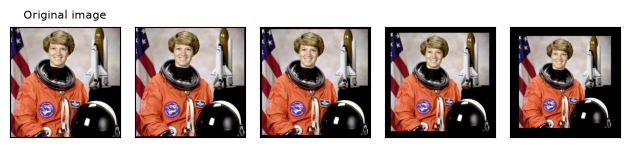

In [14]:
padded_imgs = [transforms.Pad(padding=padding)(orig_img) for padding in (3, 10, 30, 50)]
plot(padded_imgs)

## 自訂資料集(Custom Dataset)


In [15]:
# 目標名稱 --> 目標代碼
labels_code = {v.lower(): k for k, v in labels_map.items()}

In [16]:
class CustomImageDataset(Dataset):
    def __init__(
        self, img_dir: str, transform: Callable | None = None, target_transform: Callable | None = None
    ) -> None:
        self.img_labels = [file_name for file_name in os.listdir(img_dir)]
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        # 組合檔案完整路徑
        img_path = os.path.join(self.img_dir, self.img_labels[idx])
        # 讀取圖檔
        image = read_image(img_path)
        # 去除副檔名
        label = self.img_labels[idx].split('.')[0]
        # 將檔名數字去除
        label = re.sub('[0-9]', '', label)

        # 轉換
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        # 將三維轉為二維
        image = image.reshape(*image.shape[1:])
        # 反轉顏色，顏色0為白色，與 RGB 色碼不同，它的 0 為黑色
        image = 1.0 - image
        label = labels_code[label.lower()]

        return image, label

In [ ]:
# 模型載入
model: nn.Sequential = torch.load('./FashionMNIST.pt', weights_only=False)

In [ ]:
# 建立 transforms
transform = transforms.Compose(
    [
        transforms.Grayscale(),
        transforms.Resize((28, 28)),
        transforms.CenterCrop(28),
        # transforms.PILToTensor(),
        transforms.ConvertImageDtype(torch.float),
    ]
)

# 建立 DataLoader
test_loader = DataLoader(CustomImageDataset('./fashion_test_data', transform), shuffle=False, batch_size=10)

model.eval()
criterion = nn.CrossEntropyLoss()
test_loss = 0
correct = 0
with torch.no_grad():
    data: torch.Tensor
    target: torch.Tensor
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output: torch.Tensor = model(data)
        # sum up batch loss
        test_loss += criterion.forward(output, target).item()

        # 預測
        pred = output.argmax(dim=1, keepdim=True)

        # 正確筆數
        correct += pred.eq(target.view_as(pred)).sum().item()

# 平均損失
test_loss /= len(test_ds.data)
# 顯示測試結果
data_count = len(test_ds.data)
percentage = 100.0 * correct / data_count
print(f'平均損失: {test_loss:.4f}, 準確率: {correct}/{data_count} ({percentage:.0f}%)\n')

平均損失: 0.4873, 準確率: 3/7 (43%)



In [98]:
# 一次取一『批』資料
data, target = next(iter(test_loader))
print(data.shape, target)

torch.Size([7, 28, 28]) tensor([8, 5, 5, 6, 0, 1, 1])
